# Augmentation Pipeline — Mechatronics Vision 2026

**Purpose.** End-to-end, annotation-aware augmentation for YOLO-formatted data
(polygon segmentation OR bounding boxes). Intended as the *offline* reference
and the *online* per-epoch generator consumed by `cnn_transfer.ipynb`.

**What this notebook does**
1. Reads YOLO label files and auto-detects `polygon` vs `bbox` format.
2. Converts polygon labels to bbox labels via L∞-norm of vertex coordinates.
3. Builds an annotation-aware augmentation pipeline (albumentations) covering
   crop, resize, flip, rotation, skew, color jitter, channel dropout, cutout,
   Gaussian noise, Gaussian blur, Sobel filter.
4. Uses a **mask-based** geometric pipeline so polygon edges follow the image
   correctly after crop/rotate/skew (equivalent to Sutherland-Hodgman clipping
   at crop boundaries).
5. Provides a PyTorch `Dataset` that re-samples augmentations every epoch.
6. Sanity-check cell that renders augmented images with overlaid polygons.

**Design note on cutout.** Cutout / CoarseDropout alters the *image only* —
the underlying polygon annotation is preserved intact. The network sees an
occluder rather than a "the object is gone" signal, which is the correct
behavior for invariance learning.

**Data assumptions.**
- Images in `data_2026/raw/` (`.png`), labels in `data_2026/labels/` (`.txt`).
- Filename stems match 1:1 between images and labels.
- Classes: `0=firetruck, 1=fire, 2=ambulance, 3=blood`.


In [3]:
import os, sys, json, glob, math, random, shutil
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

print('torch', torch.__version__, '| cuda', torch.cuda.is_available(),
      '| albumentations', A.__version__, '| cv2', cv2.__version__)

torch 2.11.0 | cuda False | albumentations 2.0.8 | cv2 4.13.0


## 1. Configuration

**Shared with `cnn_transfer.ipynb` and `deploy.py` via `vision_config.py`.**
Change a value in that file and all three pick it up on their next run.
To try a one-off value in *this* notebook only, just reassign the variable
in the cell below after the `from vision_config import *` line.

In [4]:
import sys
sys.path.insert(0, '/Users/jnoael/Mechatronics_Vision_2026')
from vision_config import *   # PROJECT_ROOT, IMAGES_DIR, POLY_LABELS, BBOX_LABELS,
                              # CLASS_NAMES, IMAGE_SIZE, AUG_PROBS, CUTOUT_FRAC,
                              # CROP_SCALE, ROTATE_DEG, SKEW_DEG, CUTOUT_HOLES,
                              # LABEL_KIND, resolved_labels_dir(), ...

# Which label folder this notebook operates on. Resolved from LABEL_KIND in
# vision_config.py — override here only for a one-off experiment.
LABELS_DIR   = resolved_labels_dir()
BBOX_OUT_DIR = BBOX_LABELS          # where §3 writes polygon→bbox conversions

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
summary()
print(f'  active labels dir: {LABELS_DIR}')


config loaded


## 2. Label I/O

Auto-detects per-line format:
- 5 tokens → bbox (`class cx cy w h`)
- ≥ 7 odd tokens → polygon (`class x1 y1 x2 y2 ...`)

All coordinates remain normalized to `[0, 1]`.

In [5]:
def detect_format(tokens: List[float]) -> str:
    """Heuristic: bbox has exactly 5 tokens, polygon has odd >= 7."""
    n = len(tokens)
    if n == 5:
        return 'bbox'
    if n >= 7 and (n - 1) % 2 == 0:
        return 'polygon'
    raise ValueError(f'unrecognized label shape: {n} tokens')

def read_label(path: Path) -> List[Dict]:
    """Return list of {'class': int, 'kind': 'bbox'|'polygon', 'coords': np.ndarray}.
    Polygon coords shape (N,2); bbox coords shape (4,) = (cx,cy,w,h)."""
    items = []
    text = Path(path).read_text().strip()
    if not text:
        return items
    for line in text.splitlines():
        parts = line.split()
        if not parts: continue
        cls  = int(parts[0])
        nums = [float(x) for x in parts[1:]]
        kind = detect_format([cls] + nums)
        if kind == 'bbox':
            items.append(dict(cls=cls, kind='bbox', coords=np.array(nums, dtype=np.float32)))
        else:
            pts = np.array(nums, dtype=np.float32).reshape(-1, 2)
            items.append(dict(cls=cls, kind='polygon', coords=pts))
    return items

def write_label(path: Path, items: List[Dict]) -> None:
    lines = []
    for it in items:
        c = it['coords']
        if it['kind'] == 'bbox':
            lines.append(f"{it['cls']} " + ' '.join(f'{v:.6f}' for v in c))
        else:
            flat = c.reshape(-1)
            lines.append(f"{it['cls']} " + ' '.join(f'{v:.6f}' for v in flat))
    Path(path).write_text('\n'.join(lines) + ('\n' if lines else ''))

# quick self-test on first file
sample_label = next(iter(sorted(LABELS_DIR.glob('*.txt'))))
parsed = read_label(sample_label)
print(f'{sample_label.name}: {len(parsed)} instance(s)')
for p in parsed:
    print(f"  cls={p['cls']} kind={p['kind']} shape={p['coords'].shape}")


ambulance_0001.txt: 1 instance(s)
  cls=2 kind=polygon shape=(82, 2)


## 3. Polygon → Bounding-Box Converter ($L_\infty$)

For each polygon, the bbox is the axis-aligned rectangle whose sides are the
extremal vertex coordinates: `x_min=min(x_i)`, `x_max=max(x_i)`, same for `y`.
This is exactly the L∞-norm envelope. YOLO bbox format is
`class cx cy w h` with `cx=(x_min+x_max)/2`, `cy=(y_min+y_max)/2`,
`w=x_max-x_min`, `h=y_max-y_min`. Width comes before height.

In [6]:
def poly_to_bbox(pts: np.ndarray) -> np.ndarray:
    x_min, y_min = pts.min(axis=0)
    x_max, y_max = pts.max(axis=0)
    cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
    w,  h  =  x_max - x_min,      y_max - y_min
    return np.array([cx, cy, w, h], dtype=np.float32)

def convert_labels_poly_to_bbox(src_dir: Path, dst_dir: Path) -> int:
    dst_dir.mkdir(parents=True, exist_ok=True)
    n = 0
    for f in sorted(src_dir.glob('*.txt')):
        items = read_label(f)
        out = []
        for it in items:
            if it['kind'] == 'polygon':
                out.append(dict(cls=it['cls'], kind='bbox',
                                coords=poly_to_bbox(it['coords'])))
            else:
                out.append(it)
        write_label(dst_dir / f.name, out); n += 1
    return n

n_written = convert_labels_poly_to_bbox(LABELS_DIR, BBOX_OUT_DIR)
print(f'wrote {n_written} bbox label files to {BBOX_OUT_DIR}')
print('sample:', next(iter(BBOX_OUT_DIR.glob('*.txt'))).read_text().splitlines()[0])


wrote 40 bbox label files to /Users/jnoael/Mechatronics_Vision_2026/data_2026/labels_bbox
sample: 1 0.497981 0.494380 0.223911 0.522386


## 4. Annotation-aware Augmentation Pipeline

**Geometric ops run on a mask stack** — one binary mask per polygon instance.
After transform, `cv2.findContours` re-derives new polygon vertices. This
automatically handles crop clipping (equivalent to Sutherland-Hodgman),
rotation, flip, resize, and shear without manual geometry.

**Photometric + occlusion ops** (color jitter, channel dropout, cutout,
Gauss noise, Gauss blur, Sobel) touch the image only — masks are untouched,
so polygons stay intact as designed.

In [7]:
def polys_to_mask_stack(polys: List[np.ndarray], h: int, w: int) -> np.ndarray:
    """Rasterize each normalized polygon to its own uint8 mask (H,W)."""
    stack = np.zeros((len(polys), h, w), dtype=np.uint8)
    for i, poly in enumerate(polys):
        pix = (poly * np.array([w, h])).round().astype(np.int32)
        cv2.fillPoly(stack[i], [pix], 1)
    return stack

def mask_to_polys(mask: np.ndarray, min_area_px: int = 16) -> List[np.ndarray]:
    """Recover normalized polygons from a single binary mask.
    Returns a list — a single instance may split into multiple pieces."""
    h, w = mask.shape
    contours, _ = cv2.findContours((mask > 0).astype(np.uint8),
                                   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_KCOS)
    out = []
    for c in contours:
        if cv2.contourArea(c) < min_area_px: continue
        pts = c.reshape(-1, 2).astype(np.float32)
        pts[:, 0] /= w; pts[:, 1] /= h
        if len(pts) >= 3:
            out.append(pts)
    return out

class SobelLambda(A.ImageOnlyTransform):
    """Applies a Sobel magnitude filter, keeps 3-channel RGB output."""
    def __init__(self, p=0.5):
        super().__init__(p=p)
    def apply(self, img, **params):
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
        mag = np.sqrt(gx**2 + gy**2)
        # normalise to a meaningful range — use 99th percentile so a couple of
        # bright edges do not squash everything else to zero.
        hi = np.percentile(mag, 99) + 1e-6
        mag = np.clip(255 * mag / hi, 0, 255).astype(np.uint8)
        edge_rgb = cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)
        # Blend with original so the frame can never go fully black.
        return cv2.addWeighted(img, 0.35, edge_rgb, 0.65, 0)
    def get_transform_init_args_names(self):
        return ()

def build_aug(img_size: int = IMAGE_SIZE, train: bool = True) -> A.Compose:
    p = AUG_PROBS
    geo = []
    if train:
        geo += [
            A.HorizontalFlip(p=p['h_flip']),
            A.VerticalFlip(p=p['v_flip']),
            A.RandomRotate90(p=p['rotate_90']),
            A.Affine(rotate=(-ROTATE_DEG, ROTATE_DEG),
                     shear={'x': (-SKEW_DEG, SKEW_DEG), 'y': (-SKEW_DEG, SKEW_DEG)},
                     fit_output=False, p=max(p['rotate_small'], p['affine_skew'])),
            A.RandomResizedCrop(size=(img_size, img_size),
                                scale=CROP_SCALE, ratio=(0.85, 1.17),
                                p=p['random_crop']),
        ]
    geo.append(A.Resize(img_size, img_size))   # always end at target size

    photo = []
    if train:
        photo += [
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.1,
                          p=p['color_jitter']),
            A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=p['channel_dropout']),
            A.CoarseDropout(num_holes_range=CUTOUT_HOLES,
                            hole_height_range=CUTOUT_FRAC, hole_width_range=CUTOUT_FRAC,
                            fill=0, p=p['cutout']),
            A.GaussNoise(std_range=(0.04, 0.12), p=p['gauss_noise']),
            A.GaussianBlur(blur_limit=(3, 7), p=p['gauss_blur']),
            SobelLambda(p=p['sobel']),
        ]
    return A.Compose(geo + photo)

AUG_TRAIN = build_aug(train=True)
AUG_VAL   = build_aug(train=False)
print('augmentation pipelines ready')


augmentation pipelines ready


## 5. Per-epoch Re-sampling Dataset

Every `__getitem__` call re-samples augmentations, so each epoch sees fresh
views of the same underlying data. Returns the image tensor and a list of
`(class_id, polygon_xy)` pairs per sample.

In [8]:
class SegAugDataset(Dataset):
    """YOLO-seg folder → augmented (image, [ (cls, poly_norm) ]) pairs.
    Polygons are re-derived from masks after every transform."""
    def __init__(self, images_dir: Path, labels_dir: Path,
                 transform: A.Compose, img_size: int = IMAGE_SIZE,
                 return_tensor: bool = True):
        self.items = []
        for img_p in sorted(Path(images_dir).iterdir()):
            if img_p.suffix.lower() not in {'.png', '.jpg', '.jpeg'}: continue
            lab_p = Path(labels_dir) / (img_p.stem + '.txt')
            if lab_p.exists():
                self.items.append((img_p, lab_p))
        self.transform     = transform
        self.img_size      = img_size
        self.return_tensor = return_tensor

    def __len__(self):  return len(self.items)

    def __getitem__(self, i):
        img_p, lab_p = self.items[i]
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        anns = read_label(lab_p)

        # polygon-only path for mask-based geometric augs
        polys, classes = [], []
        for a in anns:
            if a['kind'] == 'polygon':
                polys.append(a['coords']); classes.append(a['cls'])
            else:
                # bbox → rectangle polygon so the same pipeline applies
                cx, cy, bw, bh = a['coords']
                x0, y0 = cx - bw/2, cy - bh/2; x1, y1 = cx + bw/2, cy + bh/2
                polys.append(np.array([[x0,y0],[x1,y0],[x1,y1],[x0,y1]], np.float32))
                classes.append(a['cls'])

        masks = polys_to_mask_stack(polys, h, w) if polys                 else np.zeros((0, h, w), np.uint8)

        out = self.transform(image=img, masks=list(masks))
        aug_img   = out['image']
        aug_masks = out['masks']

        new_items = []
        for cls, m in zip(classes, aug_masks):
            for new_poly in mask_to_polys(np.asarray(m)):
                new_items.append((cls, new_poly))

        if self.return_tensor:
            t = torch.from_numpy(aug_img).permute(2, 0, 1).float() / 255.0
            return t, new_items
        return aug_img, new_items

ds_train = SegAugDataset(IMAGES_DIR, LABELS_DIR, AUG_TRAIN, return_tensor=False)
ds_val   = SegAugDataset(IMAGES_DIR, LABELS_DIR, AUG_VAL,   return_tensor=False)
print(f'dataset: train={len(ds_train)} val={len(ds_val)}')


dataset: train=40 val=40


## 6. Visual Sanity Check

Renders a grid of augmented images with polygon outlines overlaid. Re-run the
cell to get different samples.

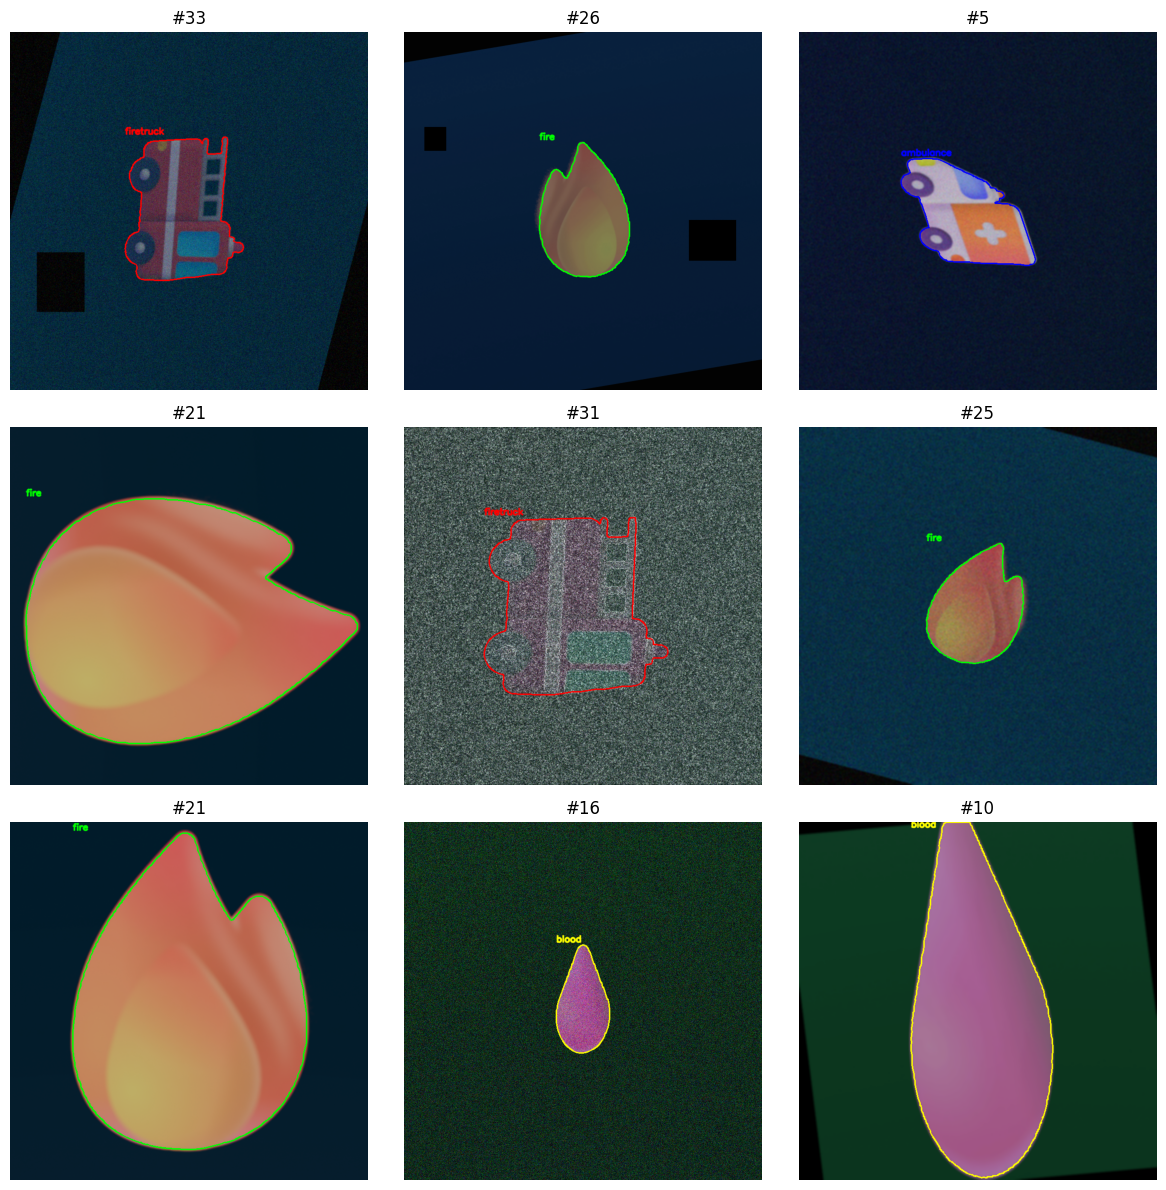

In [11]:
def overlay(img: np.ndarray, items: List[Tuple[int, np.ndarray]]) -> np.ndarray:
    canvas = img.copy()
    h, w = canvas.shape[:2]
    palette = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255),(0,255,255)]
    for cls, poly in items:
        color = palette[cls % len(palette)]
        pts = (poly * np.array([w, h])).round().astype(np.int32).reshape(-1, 1, 2)
        cv2.polylines(canvas, [pts], isClosed=True, color=color, thickness=2)
        label = CLASS_NAMES.get(cls, str(cls))
        org = pts.reshape(-1, 2).min(axis=0).tolist()
        cv2.putText(canvas, label, (int(org[0]), max(int(org[1]) - 6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
    return canvas

def grid(dataset: Dataset, n: int = 9, cols: int = 3, seed: Optional[int] = None):
    rng = random.Random(seed)
    idxs = [rng.randrange(len(dataset)) for _ in range(n)]
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    for ax, i in zip(axes.flatten(), idxs):
        img, items = dataset[i]
        if isinstance(img, torch.Tensor):
            img = (img.permute(1,2,0).numpy() * 255).astype(np.uint8)
        ax.imshow(overlay(img, items)); ax.set_title(f'#{i}'); ax.axis('off')
    for ax in axes.flatten()[len(idxs):]: ax.axis('off')
    plt.tight_layout(); plt.show()

grid(ds_train, n=9, cols=3, seed=None)


## 6b. Per-Augmentation Visualization

One image → each augmentation applied *in isolation* with probability forced
to 1.0. Lets you see exactly what every transform does and judge parameter
ranges independently of the stochastic chain in Sections 5–6. Change
`SHOWCASE_INDEX` to flip through dataset samples.

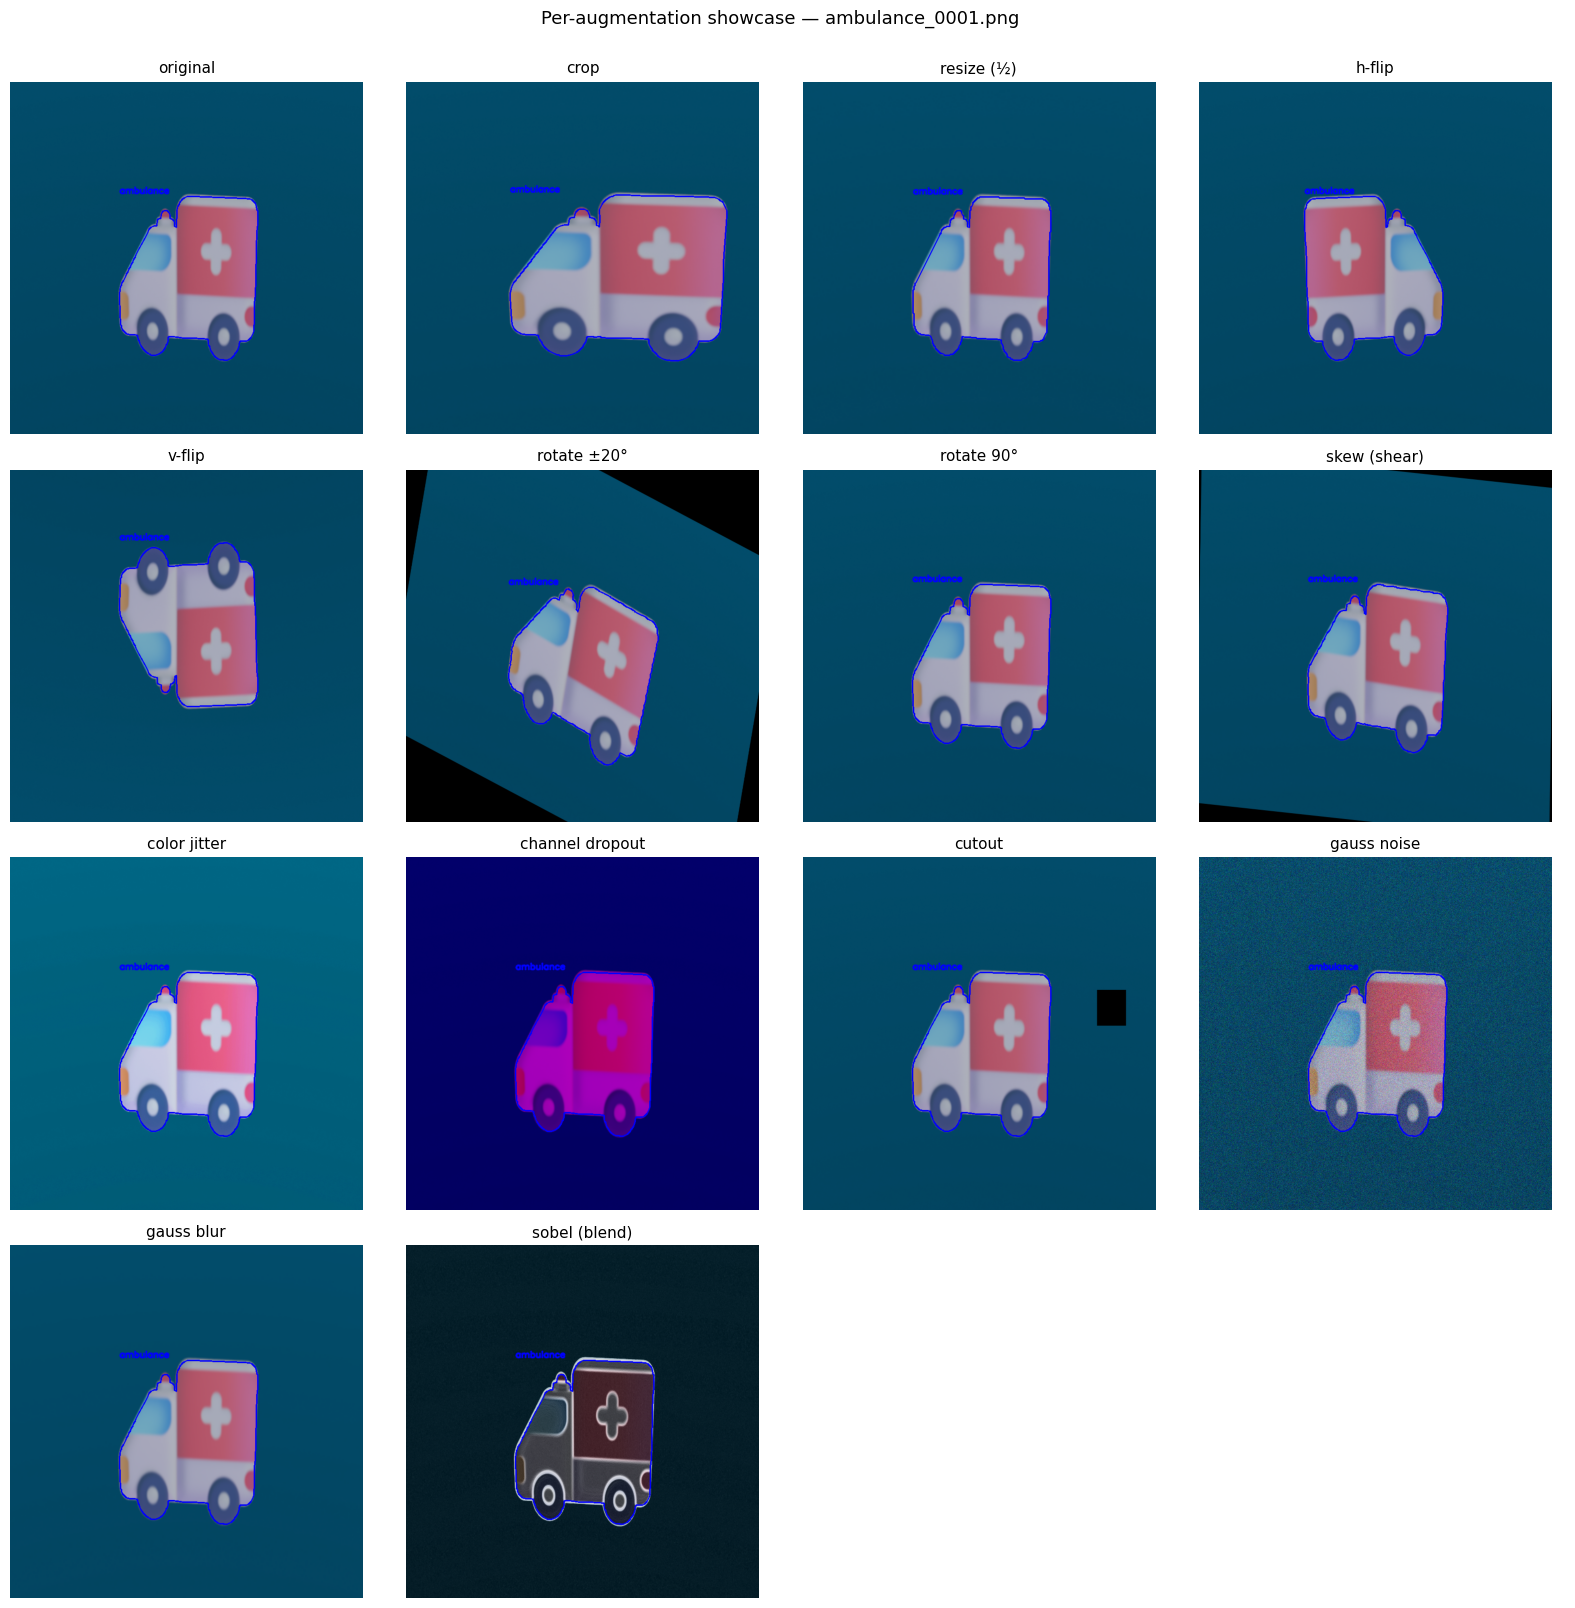

In [15]:
SHOWCASE_INDEX = 0   # which dataset item to showcase

def single_op(op: A.BasicTransform, image_size: int = IMAGE_SIZE) -> A.Compose:
    """Wrap a single op with a terminal Resize so outputs are all the same size."""
    return A.Compose([op, A.Resize(image_size, image_size)])

SHOWCASE = [
    ('original',        A.Compose([A.Resize(IMAGE_SIZE, IMAGE_SIZE)])),
    ('crop',            single_op(A.RandomResizedCrop(size=(IMAGE_SIZE, IMAGE_SIZE),
                                      scale=CROP_SCALE, ratio=(0.85, 1.17), p=1.0))),
    ('resize (½)',      A.Compose([A.Resize(IMAGE_SIZE // 2, IMAGE_SIZE // 2),
                                   A.Resize(IMAGE_SIZE, IMAGE_SIZE)])),
    ('h-flip',          single_op(A.HorizontalFlip(p=1.0))),
    ('v-flip',          single_op(A.VerticalFlip(p=1.0))),
    ('rotate ±20°',     single_op(A.Affine(rotate=(-ROTATE_DEG, ROTATE_DEG), p=1.0))),
    ('rotate 90°',      single_op(A.RandomRotate90(p=1.0))),
    ('skew (shear)',    single_op(A.Affine(shear={'x': (-SKEW_DEG, SKEW_DEG),
                                                  'y': (-SKEW_DEG, SKEW_DEG)}, p=1.0))),
    ('color jitter',    single_op(A.ColorJitter(brightness=0.2, contrast=0.2,
                                                saturation=0.3, hue=0.1, p=1.0))),
    ('channel dropout', single_op(A.ChannelDropout(p=1.0))),
    ('cutout',          single_op(A.CoarseDropout(num_holes_range=CUTOUT_HOLES,
                                                  hole_height_range=CUTOUT_FRAC,
                                                  hole_width_range=CUTOUT_FRAC,
                                                  fill=0, p=1.0))),
    ('gauss noise',     single_op(A.GaussNoise(std_range=(0.06, 0.12), p=1.0))),
    ('gauss blur',      single_op(A.GaussianBlur(blur_limit=(5, 9), p=1.0))),
    ('sobel (blend)',   single_op(SobelLambda(p=1.0))),
]

def showcase_augmentations(index: int = SHOWCASE_INDEX):
    img_p, lab_p = ds_train.items[index]
    img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
    anns = read_label(lab_p)

    # Build polygon list + mask stack once (reused for every op)
    polys, classes = [], []
    for a in anns:
        if a['kind'] == 'polygon':
            polys.append(a['coords']); classes.append(a['cls'])
        else:
            cx, cy, bw, bh = a['coords']
            x0, y0 = cx-bw/2, cy-bh/2; x1, y1 = cx+bw/2, cy+bh/2
            polys.append(np.array([[x0,y0],[x1,y0],[x1,y1],[x0,y1]], np.float32))
            classes.append(a['cls'])
    h, w = img.shape[:2]
    masks = polys_to_mask_stack(polys, h, w) if polys else np.zeros((0, h, w), np.uint8)

    n    = len(SHOWCASE)
    cols = 4
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, (name, transform) in zip(axes_flat, SHOWCASE):
        out = transform(image=img, masks=list(masks))
        aug_img   = out['image']
        aug_masks = out['masks']
        items = []
        for cls, m in zip(classes, aug_masks):
            for new_poly in mask_to_polys(np.asarray(m)):
                items.append((cls, new_poly))
        ax.imshow(overlay(aug_img, items))
        ax.set_title(name, fontsize=11)
        ax.axis('off')

    for ax in axes_flat[n:]: ax.axis('off')
    fig.suptitle(f'Per-augmentation showcase — {img_p.name}',
                 fontsize=13, y=1.002)
    plt.tight_layout(); plt.show()

showcase_augmentations(SHOWCASE_INDEX)


## 7. (Optional) Offline Bulk Export

Writes N augmented copies per source image to a new images/labels pair of
folders. Useful for training tools that don't accept a Python `Dataset`
(e.g. Ultralytics' CLI training path) or for inspection.

In [16]:
def bulk_export(src_images: Path, src_labels: Path, out_root: Path,
                copies_per_image: int = 5, kind_out: str = 'polygon') -> None:
    """kind_out in {'polygon','bbox'}. One .txt per augmented image."""
    out_img = out_root / 'images'; out_lab = out_root / 'labels'
    out_img.mkdir(parents=True, exist_ok=True); out_lab.mkdir(parents=True, exist_ok=True)

    ds = SegAugDataset(src_images, src_labels, AUG_TRAIN, return_tensor=False)
    for i in range(len(ds)):
        stem = ds.items[i][0].stem
        for k in range(copies_per_image):
            img, items = ds[i]
            name = f'{stem}_aug{k:02d}'
            cv2.imwrite(str(out_img / f'{name}.png'),
                        cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            out_items = []
            for cls, poly in items:
                if kind_out == 'bbox':
                    out_items.append(dict(cls=cls, kind='bbox',
                                          coords=poly_to_bbox(poly)))
                else:
                    out_items.append(dict(cls=cls, kind='polygon', coords=poly))
            write_label(out_lab / f'{name}.txt', out_items)
    print(f'exported {len(ds) * copies_per_image} augmented samples to {out_root}')

# uncomment to run:
# bulk_export(IMAGES_DIR, LABELS_DIR,
#             PROJECT_ROOT / 'data_2026' / 'augmented',
#             copies_per_image=10, kind_out='polygon')


## Done

Consumed by `cnn_transfer.ipynb` via identical config values.
Re-run Section 6 any time to eyeball augmentation quality — especially after
changing `AUG_PROBS` or the crop scale.